# Pangolin full finetuning — overview

## imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_SSU = "#C95D63"

## paths

In [2]:
ROOT         = ".."
FINETUNE_DIR = os.path.join(ROOT, "results", "finetuning",  "pangolin", "full")
EVAL_DIR     = os.path.join(ROOT, "results", "evaluation",  "pangolin", "full")
FOLDS_DIR    = os.path.join(ROOT, "data", "prep", "finetuning", "alphagenome", "FOLD_1")

RUN_NAME = "annotated__frozen__1gpu"
EPOCH    = 5
SAMPLES  = ["SRR17111303", "SRR17111311"]

# Pangolin pretraining split
PANGOLIN_UNSEEN_CHROMS = {"chr1", "chr3", "chr5", "chr7", "chr9"}
PANGOLIN_SEEN_CHROMS   = {
    "chr2", "chr4", "chr6", "chr8", "chr10", "chr11", "chr12", "chr13",
    "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21",
    "chr22", "chrX", "chrY",
}

## data

In [3]:
# training epoch logs
logs = pd.read_parquet(os.path.join(FINETUNE_DIR, "summary", "epoch_logs.parquet"))

# test predictions
preds_dir = os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), "test", "predictions")
ssu   = pd.read_parquet(os.path.join(preds_dir, "ssu_scores.parquet"))
ss    = pd.read_parquet(os.path.join(preds_dir, "splice_site_scores.parquet"))

# precomputed metrics
metrics = pd.read_parquet(
    os.path.join(EVAL_DIR, RUN_NAME, "epoch{}".format(EPOCH), "test", "metrics.parquet")
)

# interval BEDs for the AlphaGenome/Pangolin split
bed_seen   = pd.read_csv(
    os.path.join(FOLDS_DIR, "test_pangolin_seen_chroms.bed"),
    sep="\t", header=None, names=["chrom", "start", "end"]
)
bed_unseen = pd.read_csv(
    os.path.join(FOLDS_DIR, "test_pangolin_unseen_chroms.bed"),
    sep="\t", header=None, names=["chrom", "start", "end"]
)

print("SSU predictions shape:", ssu.shape)
print("Splice site predictions shape:", ss.shape)
print("Unique chroms in test predictions:", sorted(ssu["chrom"].unique()))
print()
print("AlphaGenome test intervals on Pangolin SEEN chroms:",   len(bed_seen),   "intervals, chroms:", sorted(bed_seen["chrom"].unique()))
print("AlphaGenome test intervals on Pangolin UNSEEN chroms:", len(bed_unseen), "intervals, chroms:", sorted(bed_unseen["chrom"].unique()))

SSU predictions shape: (1705863, 8)
Splice site predictions shape: (1705863, 11)
Unique chroms in test predictions: ['chr10', 'chr11', 'chr12', 'chr13', 'chr15', 'chr17', 'chr18', 'chr2', 'chr20', 'chr22', 'chr3', 'chr4', 'chr7', 'chr8']

AlphaGenome test intervals on Pangolin SEEN chroms: 5043 intervals, chroms: ['chr10', 'chr11', 'chr12', 'chr13', 'chr15', 'chr17', 'chr18', 'chr2', 'chr20', 'chr22', 'chr4', 'chr8']
AlphaGenome test intervals on Pangolin UNSEEN chroms: 1316 intervals, chroms: ['chr3', 'chr7']


## figures

### training and validation loss

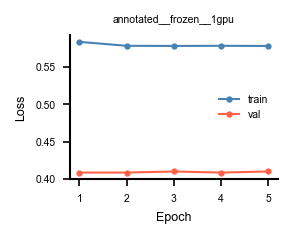

In [4]:
fig, ax = plt.subplots(figsize=(5 * cm, 4 * cm))

sub = logs.query("run_name == @RUN_NAME")
ax.plot(sub["epoch"], sub["train_loss"], label="train", color="steelblue", linewidth=1, marker="o", markersize=2)
ax.plot(sub["epoch"], sub["val_loss"],   label="val",   color="tomato",    linewidth=1, marker="o", markersize=2)

ax.set_xlabel("Epoch", fontsize=6)
ax.set_ylabel("Loss",  fontsize=6)
ax.set_title(RUN_NAME, fontsize=5)
ax.tick_params(labelsize=5)
ax.legend(fontsize=5, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### SSU correlations — all test intervals

In [5]:
def compute_ssu_corr(df, label):
    """Compute SSU Pearson r per sample and mean; return a tidy DataFrame."""
    rows = []
    for sample, sub in df.groupby("sample_id"):
        sub = sub.dropna(subset=["pred_ssu", "obs_ssu"])
        r, _ = stats.pearsonr(sub["pred_ssu"], sub["obs_ssu"])
        rows.append({"sample_id": sample, "pearson_r": r, "n": len(sub), "subset": label})
    mean_r = np.mean([r["pearson_r"] for r in rows])
    mean_n = int(np.mean([r["n"] for r in rows]))
    rows.append({"sample_id": "mean", "pearson_r": mean_r, "n": mean_n, "subset": label})
    return pd.DataFrame(rows)


# --- all test intervals, all alpha_juncs ---
corr_all = compute_ssu_corr(ssu, "all (alpha >= 1)")

# --- all test intervals, alpha_juncs >= 5 ---
corr_a5 = compute_ssu_corr(ssu.query("alpha_juncs >= 5"), "all (alpha >= 5)")

# --- Pangolin UNSEEN chroms only (common test set) ---
ssu_unseen = ssu[ssu["chrom"].isin(PANGOLIN_UNSEEN_CHROMS)]
corr_unseen    = compute_ssu_corr(ssu_unseen, "Pangolin unseen (alpha >= 1)")
corr_unseen_a5 = compute_ssu_corr(ssu_unseen.query("alpha_juncs >= 5"), "Pangolin unseen (alpha >= 5)")

# --- Pangolin SEEN chroms only ---
ssu_seen = ssu[ssu["chrom"].isin(PANGOLIN_SEEN_CHROMS)]
corr_seen    = compute_ssu_corr(ssu_seen, "Pangolin seen (alpha >= 1)")
corr_seen_a5 = compute_ssu_corr(ssu_seen.query("alpha_juncs >= 5"), "Pangolin seen (alpha >= 5)")

corr_all_combined = pd.concat(
    [corr_all, corr_a5, corr_seen, corr_seen_a5, corr_unseen, corr_unseen_a5],
    ignore_index=True
)

print(corr_all_combined.to_string(index=False))

  sample_id  pearson_r      n                       subset
SRR17111303   0.502223 819412             all (alpha >= 1)
SRR17111311   0.532540 886451             all (alpha >= 1)
       mean   0.517382 852931             all (alpha >= 1)
SRR17111303   0.355651 524493             all (alpha >= 5)
SRR17111311   0.410914 546341             all (alpha >= 5)
       mean   0.383283 535417             all (alpha >= 5)
SRR17111303   0.504279 628445   Pangolin seen (alpha >= 1)
SRR17111311   0.539917 680193   Pangolin seen (alpha >= 1)
       mean   0.522098 654319   Pangolin seen (alpha >= 1)
SRR17111303   0.360685 402467   Pangolin seen (alpha >= 5)
SRR17111311   0.421056 420341   Pangolin seen (alpha >= 5)
       mean   0.390871 411404   Pangolin seen (alpha >= 5)
SRR17111303   0.495502 190967 Pangolin unseen (alpha >= 1)
SRR17111311   0.507369 206258 Pangolin unseen (alpha >= 1)
       mean   0.501435 198612 Pangolin unseen (alpha >= 1)
SRR17111303   0.338261 122026 Pangolin unseen (alpha >= 

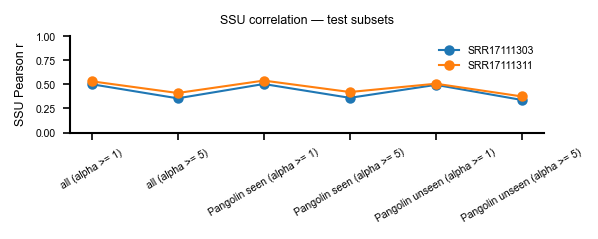

In [6]:
SUBSETS_ORDER = [
    "all (alpha >= 1)",
    "all (alpha >= 5)",
    "Pangolin seen (alpha >= 1)",
    "Pangolin seen (alpha >= 5)",
    "Pangolin unseen (alpha >= 1)",
    "Pangolin unseen (alpha >= 5)",
]

plot_df = corr_all_combined[corr_all_combined["sample_id"].isin(SAMPLES)].copy()
plot_df["subset"] = pd.Categorical(plot_df["subset"], categories=SUBSETS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10 * cm, 4 * cm))

for sample, sub in plot_df.groupby("sample_id"):
    sub = sub.sort_values("subset")
    ax.plot(
        sub["subset"].astype(str), sub["pearson_r"],
        marker="o", markersize=4, linewidth=1, label=sample
    )

ax.set_ylabel("SSU Pearson r", fontsize=6)
ax.set_xlabel("", fontsize=6)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", labelsize=5, rotation=30)
ax.tick_params(axis="y", labelsize=5)
ax.legend(fontsize=5, frameon=False)
ax.set_title("SSU correlation — test subsets", fontsize=6)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### SSU scatter — pred vs obs (all test, alpha >= 1)

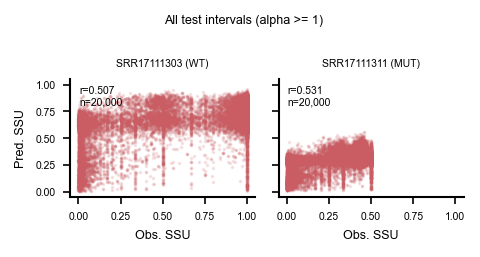

In [7]:
SAMPLE_NAMES = {"SRR17111303": "SRR17111303 (WT)", "SRR17111311": "SRR17111311 (MUT)"}
N_SCATTER    = 20000

fig, axes = plt.subplots(
    1, len(SAMPLES),
    figsize=(len(SAMPLES) * 4 * cm, 4 * cm),
    sharex=True, sharey=True,
)

for ax, sample in zip(axes, SAMPLES):
    sub = ssu.query("sample_id == @sample").dropna(subset=["pred_ssu", "obs_ssu"])
    sub = sub.sample(min(N_SCATTER, len(sub)), random_state=42)
    r, _ = stats.pearsonr(sub["pred_ssu"], sub["obs_ssu"])
    ax.scatter(
        sub["obs_ssu"], sub["pred_ssu"],
        s=0.5, alpha=0.15, rasterized=True, color=PAL_SSU
    )
    ax.text(0.05, 0.95, "r={:.3f}\nn={:,}".format(r, len(sub)),
            transform=ax.transAxes, fontsize=5, va="top")
    ax.set_title(SAMPLE_NAMES[sample], fontsize=5)
    ax.set_xlabel("Obs. SSU",  fontsize=6)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=5)
    sns.despine(ax=ax)

axes[0].set_ylabel("Pred. SSU", fontsize=6)
plt.suptitle("All test intervals (alpha >= 1)", fontsize=6, y=1.02)
plt.tight_layout()
plt.show()

### SSU scatter — pred vs obs (alpha >= 5)

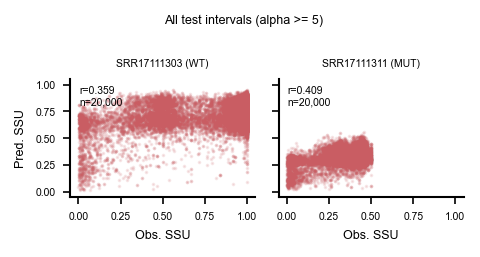

In [8]:
ssu_a5 = ssu.query("alpha_juncs >= 5")

fig, axes = plt.subplots(
    1, len(SAMPLES),
    figsize=(len(SAMPLES) * 4 * cm, 4 * cm),
    sharex=True, sharey=True,
)

for ax, sample in zip(axes, SAMPLES):
    sub = ssu_a5.query("sample_id == @sample").dropna(subset=["pred_ssu", "obs_ssu"])
    sub = sub.sample(min(N_SCATTER, len(sub)), random_state=42)
    r, _ = stats.pearsonr(sub["pred_ssu"], sub["obs_ssu"])
    ax.scatter(
        sub["obs_ssu"], sub["pred_ssu"],
        s=0.5, alpha=0.15, rasterized=True, color=PAL_SSU
    )
    ax.text(0.05, 0.95, "r={:.3f}\nn={:,}".format(r, len(sub)),
            transform=ax.transAxes, fontsize=5, va="top")
    ax.set_title(SAMPLE_NAMES[sample], fontsize=5)
    ax.set_xlabel("Obs. SSU",  fontsize=6)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=5)
    sns.despine(ax=ax)

axes[0].set_ylabel("Pred. SSU", fontsize=6)
plt.suptitle("All test intervals (alpha >= 5)", fontsize=6, y=1.02)
plt.tight_layout()
plt.show()

### SSU scatter — common test intervals (Pangolin unseen chroms: chr3, chr7)

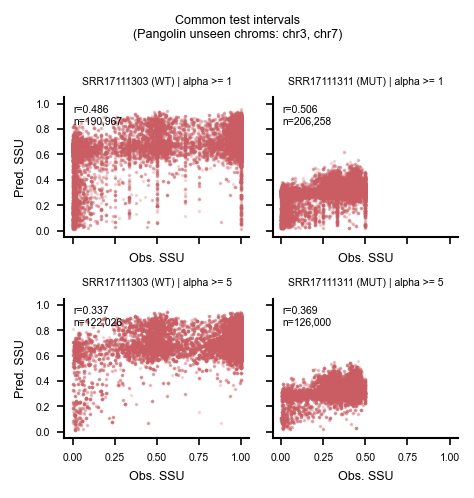

In [9]:
fig, axes = plt.subplots(
    2, len(SAMPLES),
    figsize=(len(SAMPLES) * 4 * cm, 2 * 4 * cm),
    sharex=True, sharey=True,
)

for row_i, (alpha_label, ssu_sub) in enumerate([
    ("alpha >= 1", ssu_unseen),
    ("alpha >= 5", ssu_unseen.query("alpha_juncs >= 5")),
]):
    for ax, sample in zip(axes[row_i], SAMPLES):
        sub = ssu_sub.query("sample_id == @sample").dropna(subset=["pred_ssu", "obs_ssu"])
        sub_plot = sub.sample(min(N_SCATTER, len(sub)), random_state=42)
        r, _ = stats.pearsonr(sub_plot["pred_ssu"], sub_plot["obs_ssu"])
        ax.scatter(
            sub_plot["obs_ssu"], sub_plot["pred_ssu"],
            s=0.5, alpha=0.2, rasterized=True, color=PAL_SSU
        )
        ax.text(0.05, 0.95, "r={:.3f}\nn={:,}".format(r, len(sub)),
                transform=ax.transAxes, fontsize=5, va="top")
        ax.set_title("{} | {}".format(SAMPLE_NAMES[sample], alpha_label), fontsize=5)
        ax.set_xlabel("Obs. SSU",  fontsize=6)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(labelsize=5)
        sns.despine(ax=ax)
    axes[row_i][0].set_ylabel("Pred. SSU", fontsize=6)

plt.suptitle("Common test intervals\n(Pangolin unseen chroms: chr3, chr7)", fontsize=6, y=1.02)
plt.tight_layout()
plt.show()

### Splice site auPRC

In [10]:
from sklearn.metrics import average_precision_score

roles = ["donor_pos", "acceptor_pos", "donor_neg", "acceptor_neg"]

auprc_rows = []
for sample, sub in ss.groupby("sample_id"):
    for role in roles:
        pred_col = "pred_{}".format(role)
        if pred_col not in ss.columns:
            continue
        valid = sub.dropna(subset=[pred_col, "label_rnaseq"])
        auprc = average_precision_score(valid["label_rnaseq"], valid[pred_col])
        auprc_rows.append({"sample_id": sample, "role": role, "auPRC": auprc, "n": len(valid)})

auprc_df = pd.DataFrame(auprc_rows)
print(auprc_df.to_string(index=False))

  sample_id         role  auPRC      n
SRR17111303    donor_pos    1.0 819412
SRR17111303 acceptor_pos    1.0 819412
SRR17111303    donor_neg    1.0 819412
SRR17111303 acceptor_neg    1.0 819412
SRR17111311    donor_pos    1.0 886451
SRR17111311 acceptor_pos    1.0 886451
SRR17111311    donor_neg    1.0 886451
SRR17111311 acceptor_neg    1.0 886451


### Summary table — SSU correlations with n

In [11]:
summary = corr_all_combined.copy()
summary["pearson_r"] = summary["pearson_r"].round(4)
summary = summary.sort_values(["subset", "sample_id"]).reset_index(drop=True)
display(summary)

,sample_id,pearson_r,n,subset
0,SRR17111303,0.5043,628445,Pangolin seen (alpha >= 1)
1,SRR17111311,0.5399,680193,Pangolin seen (alpha >= 1)
2,mean,0.5221,654319,Pangolin seen (alpha >= 1)
3,SRR17111303,0.3607,402467,Pangolin seen (alpha >= 5)
4,SRR17111311,0.4211,420341,Pangolin seen (alpha >= 5)
5,mean,0.3909,411404,Pangolin seen (alpha >= 5)
6,SRR17111303,0.4955,190967,Pangolin unseen (alpha >= 1)
7,SRR17111311,0.5074,206258,Pangolin unseen (alpha >= 1)
8,mean,0.5014,198612,Pangolin unseen (alpha >= 1)
9,SRR17111303,0.3383,122026,Pangolin unseen (alpha >= 5)
